In [3]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [19]:
class BMI(TypedDict):
    weight:float
    height:float
    bmi:float
    category:str

In [20]:
def calculate_bmi(state: BMI) -> BMI:
    w=state['weight']
    h=state['height']
    state['bmi']=w/(h*h)
    return state

def get_cat(state: BMI) -> BMI:
    if(state['bmi']>24):
        state['category']='overweight'
    elif(state['bmi']<18):
        state['category']='underweight'
    else:
        state['category']='fit'
    return state

In [21]:
graph = StateGraph(BMI)

graph.add_node('bmi calc', calculate_bmi)
graph.add_node('get_category', get_cat)
graph.add_edge(START, 'bmi calc')
graph.add_edge('bmi calc', 'get_category')
graph.add_edge('bmi calc', END)

workflow=graph.compile()

In [22]:
workflow.invoke({'weight':800, 'height':158.2})

{'weight': 800,
 'height': 158.2,
 'bmi': 0.03196517074995086,
 'category': 'underweight'}

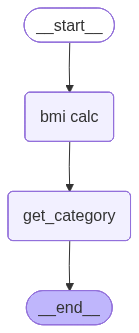

In [23]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())